In [10]:
import pandas as pd
import numpy as np
import openai
import os
import re
import sys
from langchain.vectorstores import Chroma
from langchain.text_splitter import TokenTextSplitter
from langchain.docstore.document import Document
from langchain.embeddings import OpenAIEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import tiktoken

In [11]:
# Initialize OpenAI API
openai.api_key = "your-openai-api-key"

In [26]:

df = pd.read_csv('/vegan/top5_cluster_hdbscan_vegan_iter1_new.csv', index_col=False)

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.reset_index(drop=True)
print(df.columns, df.shape)

Index(['index', 'name', 'uid', 'location', 'description', 'tweet_id',
       'created_at', 'text', 'len', 'likes', 'retweets', 'proc_text',
       'cluster'],
      dtype='object') (1795, 13)


In [4]:
#df

## generate summary


In [5]:
import openai
import pandas as pd

# # Set your OpenAI API key
# openai.api_key = "your-openai-api-key"
openai.api_key = ''

# Function to get GPT-4 summary for each cluster
def generate_gpt4_summary(texts):
    prompt = f"Summarize the following tweets: \n{texts}"
    response = openai.ChatCompletion.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=150
    )
    summary = response['choices'][0]['message']['content']
    return summary

# Group by clusters and summarize the top tweets for each cluster
cluster_summaries = {}
clusters = df['cluster'].unique()
#print(len(clusters),clusters[0], clusters[358] )
com = []
for cluster_id in clusters:
    # print(cluster_id)
    # Get the top 5 tweets for the cluster
    cluster_texts = df[df['cluster'] == cluster_id]['proc_text'].tolist()
    # print(cluster_texts)
    combined_text = ' '.join(cluster_texts[:5])  # Combine top 5 tweets into one string
    #com.append(combined_text)
# print(len(com))
    # Generate GPT-4 summary
    summary = generate_gpt4_summary(combined_text)
    cluster_summaries[cluster_id] = summary

# # Print or save the summaries
# for cluster_id, summary in cluster_summaries.items():
#     print(f"Cluster {cluster_id} Summary: {summary}")

# Assuming cluster_summaries is already generated as a dictionary {cluster_id: summary}
# Create a DataFrame with the cluster summaries
summary_data = {'cluster': list(cluster_summaries.keys()), 'summary': list(cluster_summaries.values())}
summary_df = pd.DataFrame(summary_data)

# Save the DataFrame to a CSV file
output_file_path = '/vegan/cluster_summaries_gpt4.csv'  # Adjust the path as needed
summary_df.to_csv(output_file_path, index=False)


In [6]:
df.columns

Index(['index', 'name', 'uid', 'location', 'description', 'tweet_id',
       'created_at', 'text', 'len', 'likes', 'retweets', 'proc_text',
       'cluster'],
      dtype='object')

## Check coherency

In [13]:
df_sum = pd.read_csv('/vegan/cluster_summaries_gpt4.csv', index_col=False)

In [14]:
import openai
import pandas as pd

# Set your OpenAI API key
openai.api_key = ''

# Function to check coherence with a simple yes/no answer from GPT-4
def check_coherence(tweet_texts, summary):
    prompt = f"""
    Do the following tweets share a common theme with this summary? 
    Please answer with a 'yes' or 'no'.
    
    Tweets:
    {tweet_texts}
    
    Summary:
    {summary}
    """
    
    response = openai.ChatCompletion.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=50
    )
    
    feedback = response['choices'][0]['message']['content'].strip().lower()
    return feedback  # This should be 'yes' or 'no'



# Merge the datasets based on the cluster column
df_merged = pd.merge(df, df_sum, on='cluster', how='left')
#print(df_merged)
# Initialize an action column to store coherence decision
df_merged['coherence_decision'] = None

# Iterate over each cluster, check coherence, and decide action
for cluster_id in df_merged['cluster'].unique():
    # Extract tweets and summary for the current cluster
    cluster_tweets = df_merged[df_merged['cluster'] == cluster_id]['proc_text'].tolist()
    cluster_summary = df_merged[df_merged['cluster'] == cluster_id]['summary'].iloc[0]
    
    # Check coherence using GPT-4
    feedback = check_coherence(cluster_tweets, cluster_summary)
    df_merged['coherency_check'] = feedback
    # # Assign coherence decision based on GPT-4 feedback
    # if feedback == "yes":
    #     df_merged.loc[df_merged['cluster'] == cluster_id, 'coherence_decision'] = 'coherent'
    # else:
    #     df_merged.loc[df_merged['cluster'] == cluster_id, 'coherence_decision'] = 'incoherent'

# Save the resulting actions to a CSV file
df_merged.to_csv('/vegan/cluster_coherence_decisions.csv', index=False)


In [8]:
#df_merged.to_csv('/vegan/cluster_coherence_decisions.csv', index=False)

In [15]:
# # Assuming df_tweets and df_summaries are already loaded
# df_merged = pd.merge(df, df_sum, on='cluster', how='left')
# df_merged
# # The resulting DataFrame 'df_merged' will have both tweet texts and their corresponding summaries.


## Merge cluster

In [19]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

df_merged = pd.read_csv('/vegan/cluster_coherence_decisions.csv', index_col=False)

# Initialize the SentenceTransformer model for generating embeddings
model = SentenceTransformer('all-mpnet-base-v2')

# Generate embeddings for the cluster summaries
summaries = df_merged.drop_duplicates(subset=['cluster'])['summary'].tolist()
summary_embeddings = model.encode(summaries)

# Compute cosine similarity between all pairs of cluster summaries
similarity_matrix = cosine_similarity(summary_embeddings)

# Set a threshold for merging clusters (you can adjust this value)
similarity_threshold = 0.85

# Find overlapping clusters based on the similarity threshold
clusters = df_merged['cluster'].unique()
overlapping_clusters = []

# Iterate over the similarity matrix and identify clusters to merge
for i in range(len(clusters)):
    for j in range(i + 1, len(clusters)):
        if similarity_matrix[i][j] > = similarity_threshold:
            overlapping_clusters.append((clusters[i], clusters[j]))

# Merge clusters that are identified as overlapping
def merge_clusters(df, cluster_a, cluster_b):
    # Reassign tweets in cluster_b to cluster_a
    df.loc[df['cluster'] == cluster_b, 'cluster'] = cluster_a
    return df

# Apply merging for each overlapping cluster pair
for cluster_a, cluster_b in overlapping_clusters:
    df_merged = merge_clusters(df_merged, cluster_a, cluster_b)

# Save the updated dataset with merged clusters
df_merged.to_csv('/vegan/merged_clusters_decision.csv', index=False)

# Output the merged clusters
print(f"Overlapping clusters merged: {overlapping_clusters}")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Overlapping clusters merged: [(1, 5), (1, 6), (1, 7), (1, 10), (1, 11), (1, 12), (1, 13), (1, 23), (1, 25), (1, 48), (1, 53), (1, 67), (1, 78), (1, 79), (4, 59), (5, 7), (5, 12), (5, 48), (5, 53), (5, 67), (5, 79), (6, 7), (6, 11), (6, 12), (6, 13), (6, 23), (6, 25), (6, 48), (6, 53), (6, 67), (6, 79), (7, 10), (7, 11), (7, 12), (7, 13), (7, 25), (7, 48), (7, 53), (7, 67), (7, 78), (7, 79), (8, 15), (8, 18), (8, 27), (8, 28), (8, 40), (8, 47), (8, 56), (8, 57), (8, 58), (8, 64), (8, 65), (10, 11), (10, 12), (10, 13), (10, 25), (10, 53), (10, 67), (10, 78), (10, 79), (11, 12), (11, 13), (11, 23), (11, 25), (11, 48), (11, 53), (11, 67), (11, 78), (11, 79), (12, 13), (12, 23), (12, 25), (12, 48), (12, 53), (12, 67), (12, 78), (12, 79), (13, 23), (13, 25), (13, 48), (13, 53), (13, 67), (13, 78), (13, 79), (15, 27), (15, 28), (15, 47), (15, 52), (15, 58), (15, 64), (15, 65), (16, 17), (16, 18), (16, 27), (16, 28), (16, 40), (16, 51), (16, 56), (16, 57), (16, 71), (17, 18), (17, 27), (17, 28

## Generate merged summary

In [21]:
import pandas as pd
import openai

# Set your OpenAI API key
openai.api_key = ''

# Load the dataset (Assuming it has columns 'cluster' and 'proc_text')
df = pd.read_csv('/vegan/merged_clusters_decision.csv')

# Group tweets by cluster
grouped_tweets = df.groupby('cluster')['proc_text'].apply(lambda x: ' '.join(x)).reset_index()

# Function to generate a summary for a cluster using GPT-4
def generate_gpt4_summary(tweets):
    prompt = f"Summarize the following tweets in a concise way:\n\n{tweets}"
    response = openai.ChatCompletion.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=150
    )
    summary = response['choices'][0]['message']['content'].strip()
    return summary

# Apply GPT-4 to generate summaries for each cluster
grouped_tweets['merged_summary'] = grouped_tweets['proc_text'].apply(generate_gpt4_summary)

# Save the resulting DataFrame with new summaries
output_file_path = '/vegan/merged_clusters_with_summaries.csv'
grouped_tweets.to_csv(output_file_path, index=False)



In [22]:
# # # Assuming df_tweets and df_summaries are already loaded
# df_merged_cluster = pd.merge(df, grouped_tweets, on='cluster', how='left')
# df_merged_cluster.to_csv('/vegan/tweets_merged_clusters_summaries.csv', index=False)


In [25]:
# len(pd.unique(df_merged_cluster['cluster'])), len(pd.unique(df['cluster']))

(230, 359)

### calculate intra-cluster similarity after LLMs refinement

In [27]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset (Assuming it has 'cluster' and 'proc_text' columns for clustering and tweets)

df = pd.read_csv('/vegan/tweets_merged_clusters_summaries.csv')
# Initialize SBERT model
model = SentenceTransformer('all-mpnet-base-v2')

# Function to calculate intra-cluster similarity for a given cluster
def calculate_intra_cluster_similarity(tweets):
    # Generate embeddings for each tweet in the cluster
    embeddings = model.encode(tweets)
    
    # Compute cosine similarity for all pairs of tweet embeddings
    similarity_matrix = cosine_similarity(embeddings)
    
    # Get the upper triangular part of the similarity matrix (since it's symmetric)
    upper_triangle = np.triu(similarity_matrix, k=1)  # k=1 excludes the diagonal
    
    # Calculate the average of the upper triangular matrix
    avg_similarity = np.sum(upper_triangle) / np.count_nonzero(upper_triangle)
    
    return avg_similarity

# Group tweets by cluster
grouped = df.groupby('cluster')['proc_text_x'].apply(list).reset_index()

# Calculate intra-cluster similarity for each cluster
grouped['intra_cluster_similarity'] = grouped['proc_text_x'].apply(calculate_intra_cluster_similarity)

# Save the results to a new CSV file
output_file_path = '/vegan/intra_cluster_similarity_LLM.csv'
grouped.to_csv(output_file_path, index=False)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### intra-cluster similarity after Textual Similarity-based Merging using Sentence-BERT (SBERT)

In [28]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset (Assuming it has 'cluster' and 'proc_text' columns for clustering and tweets)
df = pd.read_csv('/vegan/refined_clusters_new_SBERT.csv')

# Initialize SBERT model
model = SentenceTransformer('all-mpnet-base-v2')

# Function to calculate intra-cluster similarity for a given cluster
def calculate_intra_cluster_similarity(tweets):
    # Generate embeddings for each tweet in the cluster
    embeddings = model.encode(tweets)
    
    # Compute cosine similarity for all pairs of tweet embeddings
    similarity_matrix = cosine_similarity(embeddings)
    
    # Get the upper triangular part of the similarity matrix (since it's symmetric)
    upper_triangle = np.triu(similarity_matrix, k=1)  # k=1 excludes the diagonal
    
    # Calculate the average of the upper triangular matrix
    avg_similarity = np.sum(upper_triangle) / np.count_nonzero(upper_triangle)
    
    return avg_similarity

# Group tweets by cluster
grouped = df.groupby('refined_cluster')['proc_text'].apply(list).reset_index()

# Calculate intra-cluster similarity for each cluster
grouped['intra_cluster_similarity_SBERT'] = grouped['proc_text'].apply(calculate_intra_cluster_similarity)

# Save the results to a new CSV file
output_file_path = '/vegan/intra_cluster_similarity_SBERT.csv'
grouped.to_csv(output_file_path, index=False)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### intra-cluster similarity before merging (direct result from HDBScan)

In [29]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset (Assuming it has 'cluster' and 'proc_text' columns for clustering and tweets)
df = pd.read_csv('/vegan/refined_clusters_new_SBERT.csv')

# Initialize SBERT model
model = SentenceTransformer('all-mpnet-base-v2')

# Function to calculate intra-cluster similarity for a given cluster
def calculate_intra_cluster_similarity(tweets):
    # Generate embeddings for each tweet in the cluster
    embeddings = model.encode(tweets)
    
    # Compute cosine similarity for all pairs of tweet embeddings
    similarity_matrix = cosine_similarity(embeddings)
    
    # Get the upper triangular part of the similarity matrix (since it's symmetric)
    upper_triangle = np.triu(similarity_matrix, k=1)  # k=1 excludes the diagonal
    
    # Calculate the average of the upper triangular matrix
    avg_similarity = np.sum(upper_triangle) / np.count_nonzero(upper_triangle)
    
    return avg_similarity

# Group tweets by cluster
grouped = df.groupby('cluster')['proc_text'].apply(list).reset_index()

# Calculate intra-cluster similarity for each cluster
grouped['intra_cluster_similarity_hdbscan'] = grouped['proc_text'].apply(calculate_intra_cluster_similarity)

# Save the results to a new CSV file
output_file_path = '/vegan/intra_cluster_similarity_hdbscan.csv'
grouped.to_csv(output_file_path, index=False)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### compare intra-cluster similarity results

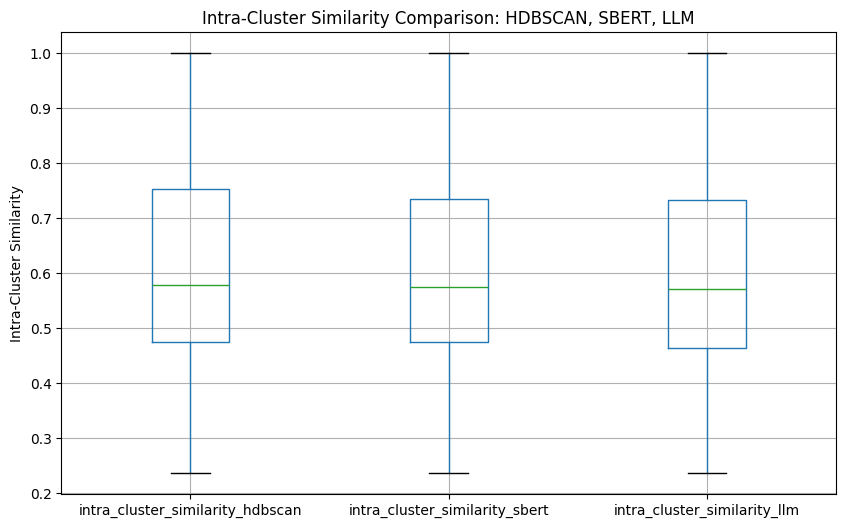

Comparison results saved to: /teamspace/studios/this_studio/Tunaz/vegan/merged_intra_cluster_similarity_comparison.csv
Descriptive statistics:
       intra_cluster_similarity_hdbscan  intra_cluster_similarity_sbert  \
count                        214.000000                      214.000000   
mean                           0.624777                        0.621783   
std                            0.202438                        0.199294   
min                            0.236743                        0.236743   
25%                            0.475512                        0.475209   
50%                            0.578668                        0.575567   
75%                            0.753511                        0.735566   
max                            1.000000                        1.000000   

       intra_cluster_similarity_llm  
count                    214.000000  
mean                       0.610955  
std                        0.195931  
min                        0.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the results from HDBSCAN, SBERT, and LLM
df_hdbscan = pd.read_csv('/vegan/intra_cluster_similarity_hdbscan.csv')
df_sbert = pd.read_csv('/vegan/intra_cluster_similarity_SBERT.csv')
df_llm = pd.read_csv('/vegan/intra_cluster_similarity_LLM.csv')

# Assuming each CSV file has a 'cluster' and 'intra_cluster_similarity' column, we merge the results
df_merged = df_hdbscan.merge(df_sbert, on='cluster', suffixes=('_hdbscan', '_sbert'))
df_merged = df_merged.merge(df_llm, on='cluster')
df_merged.rename(columns={'intra_cluster_similarity': 'intra_cluster_similarity_llm'}, inplace=True)

# Compute descriptive statistics for each method
stats = df_merged[['intra_cluster_similarity_hdbscan', 'intra_cluster_similarity_sbert', 'intra_cluster_similarity_llm']].describe()

# Visualize the results using box plots to compare the distribution of intra-cluster similarity
plt.figure(figsize=(10, 6))
df_merged[['intra_cluster_similarity_hdbscan', 'intra_cluster_similarity_sbert', 'intra_cluster_similarity_llm']].boxplot()
plt.title('Intra-Cluster Similarity Comparison: HDBSCAN, SBERT, LLM')
plt.ylabel('Intra-Cluster Similarity')
# Save the plot as an image
plt.savefig('/vegan/intra_cluster_similarity_comparison.png')
plt.show()

# Save the merged dataset with similarity scores for further analysis
output_file_path = '/vegan/merged_intra_cluster_similarity_comparison.csv'
df_merged.to_csv(output_file_path, index=False)

print(f"Comparison results saved to: {output_file_path}")
print(f"Descriptive statistics:\n{stats}")


### as it is not normal distributin. we used Wilcoxon signed-rank test

In [7]:
import pandas as pd
from scipy.stats import wilcoxon

# Load the dataset with intra-cluster similarity (assuming you have columns 'cluster', 'intra_cluster_similarity_hdbscan', 'intra_cluster_similarity_sbert', 'intra_cluster_similarity_llm')
df = pd.read_csv('/vegan/merged_intra_cluster_similarity_comparison.csv')

# Perform Wilcoxon signed-rank test (HDBSCAN vs SBERT)
wilcoxon_hdbscan_sbert = wilcoxon(df['intra_cluster_similarity_hdbscan'], df['intra_cluster_similarity_sbert'])

# Perform Wilcoxon signed-rank test (HDBSCAN vs LLM)
wilcoxon_hdbscan_llm = wilcoxon(df['intra_cluster_similarity_hdbscan'], df['intra_cluster_similarity_llm'])

# Output the results
print(f"Wilcoxon Test (HDBSCAN vs SBERT): statistic = {wilcoxon_hdbscan_sbert.statistic}, p-value = {wilcoxon_hdbscan_sbert.pvalue}")
print(f"Wilcoxon Test (HDBSCAN vs LLM): statistic = {wilcoxon_hdbscan_llm.statistic}, p-value = {wilcoxon_hdbscan_llm.pvalue}")


Wilcoxon Test (HDBSCAN vs SBERT): statistic = 440.0, p-value = 0.2722044634246342
Wilcoxon Test (HDBSCAN vs LLM): statistic = 206.0, p-value = 0.00015161277794024445
